Questo è il Notebook relativo alla task 4 del progetto.

In [75]:
# Librerie
import numpy as np
from scipy.sparse import csc_matrix, coo_matrix
from scipy.sparse.linalg import spsolve_triangular
from sksparse.cholmod import cholesky
import time
import gc
from sksparse.cholmod import cholesky, CholmodOutOfMemoryError

# Funzione che legge le matrici in formato COO e restituisce la matrice in formato CSC
def read_coo_to_csc(a_filename):
    data_A = np.loadtxt(a_filename)
    rows = data_A[:, 0].astype(int)
    cols = data_A[:, 1].astype(int)
    vals = data_A[:, 2]
    A_coo = coo_matrix((vals, (rows, cols)))
    return A_coo.tocsc()

# Funzione che legge il termine noto b
def read_rhs(rhs_filename):
    return np.loadtxt(rhs_filename)

# Funzione che calcola la fattorizzazione di Cholesky di una matrice
def my_cholesky(A):
    try:
        factor = cholesky(A, order="natural")
    except TypeError:
        factor = cholesky(A, ordering_method="natural")
    # 'factor' e' una TUPLA: factor[0] e' il fattore superiore R (A = R^T R)
    R = csc_matrix(factor[0])
    return R.T.tocsc()  # restituisce la matrice triangolare inferiore L in formato CSC

# Funzione che risolve il sistema lineare Au = b usando la fattorizzazione di Cholesky
def solve_cholesky(L, b):
    y = spsolve_triangular(L, b, lower=True)            # Risolvo L y = b
    u = spsolve_triangular(L.T.tocsc(), y, lower=False)  # Risolvo L^T u = y
    return u

#definisco una nuova funzione che fattorizza e risolve misurando i tempo MA che restituisce None se la memoria non è sufficiente
def cholesky_and_solve(A, b):
    try: 
        t0 = time.perf_counter()
        L = my_cholesky(A)
        t_fact = time.perf_counter() - t0
      

        t0 = time.perf_counter()
        u = solve_cholesky(L, b)
        t_solve = time.perf_counter() - t0

    except (CholmodOutOfMemoryError):
            gc.collect()
            return None 

    nnz_L = L.nnz
    del L
    gc.collect()
    return u, nnz_L, t_fact, t_solve

       

# --- Lettura dei dati ---
A_orig_CSC = read_coo_to_csc("A_orig.txt")
A_reordered_CSC = read_coo_to_csc("A_reordered.txt")

print("=== MATRICE ORIGINALE ===")
print(f"Dimensione : {A_orig_CSC.shape}")  # dimensione della matrice n x m
print(f"NNZ        : {A_orig_CSC.nnz}\n")  # numero di elementi non nulli

print("=== MATRICE RIORDINATA ===")
print(f"Dimensione : {A_reordered_CSC.shape}")
print(f"NNZ        : {A_reordered_CSC.nnz}\n")

# Cambio segno ad A e b: (-A) u = (-b) ha la stessa soluzione, con matrice definita positiva
A_orig = -A_orig_CSC
A_reordered = -A_reordered_CSC
b_orig = -read_rhs("rhs_orig.txt")
b_reordered = -read_rhs("rhs_reordered.txt")

#Risoluzione
res_orig = cholesky_and_solve(A_orig, b_orig)
res_reord = cholesky_and_solve(A_reordered, b_reordered)

# --- Stampa dei risultati ---

print("=== SISTEMA ORIGINALE ===")
if res_orig is None:
    print("Memoria esaurita: fattorizzazione non eseguibile con l'ordinamento naturale\n")
else:
    u_orig, nnz_orig, tf_orig, ts_orig = res_orig
    print(f"Fill-in NNZ(L)   : {nnz_orig}\n")

print("=== SISTEMA RIORDINATO ===")
if res_reord is None:
    print("Memoria esaurita anche con il riordinamento\n")
else:
    u_reord, nnz_reord, tf_reord, ts_reord = res_reord
    print(f"Fill-in NNZ(L)   : {nnz_reord}\n")

# ATTENZIONE: u_orig e u_reord contengono gli stessi valori in ordine diverso (N^2 elementi in totale)
if res_orig is not None:
    print("Primi 10 elementi della soluzione:", u_orig[:10])
if res_reord is not None:
    print("Primi 10 elementi della soluzione riordinata:", u_reord[:10])

print("\n=== PRESTAZIONI (TEMPI IN SECONDI) ===")
if res_orig is not None:
    print(f"Originale  -> Fattorizzazione: {tf_orig:.6f} s | Soluzione: {ts_orig:.6f} s | Totale: {tf_orig + ts_orig:.6f} s")
if res_reord is not None:
    print(f"Riordinato -> Fattorizzazione: {tf_reord:.6f} s | Soluzione: {ts_reord:.6f} s | Totale: {tf_reord + ts_reord:.6f} s")
if res_orig is not None and res_reord is not None:
    print(f"Speedup Fattorizzazione: {tf_orig / tf_reord:.2f}x")


=== MATRICE ORIGINALE ===
Dimensione : (1048576, 1048576)
NNZ        : 5238784

=== MATRICE RIORDINATA ===
Dimensione : (1048576, 1048576)
NNZ        : 5238784

=== SISTEMA ORIGINALE ===
Memoria esaurita: fattorizzazione non eseguibile con l'ordinamento naturale

=== SISTEMA RIORDINATO ===
Fill-in NNZ(L)   : 52721810

Primi 10 elementi della soluzione riordinata: [0.00031214 0.0005767  0.0005767  0.001087   0.00102834 0.00197661
 0.00081248 0.00154972 0.00102834 0.00197661]

=== PRESTAZIONI (TEMPI IN SECONDI) ===
Riordinato -> Fattorizzazione: 4.830336 s | Soluzione: 4.310232 s | Totale: 9.140568 s


# Task 5 — Confronto tra ordinamento naturale e nested dissection

Risolviamo $-A\,u = -b$ per $N = 32, 64, \dots, 1024$ (cioè $N^2$ incognite) con la fattorizzazione di Cholesky $-A = LL^T$,
una volta con l'ordinamento naturale di `coords.txt` e una volta con l'ordinamento di `ordering.txt` (nested dissection).
Per ogni $N$ abbiamo confrontato il numero di elementi non nulli di $L$ (fill-in) e i tempi di fattorizzazione e di soluzione.
Generiamo poi i grafici delle soluzioni e delle immagini delle strutture della matrici con e senza riordinamento della nested-dissection.

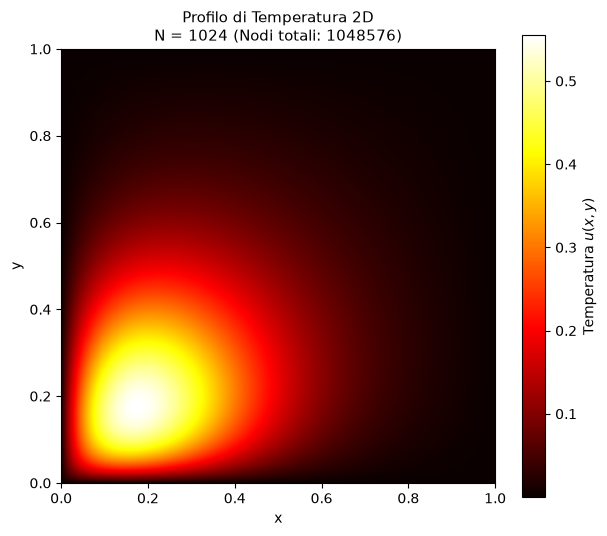

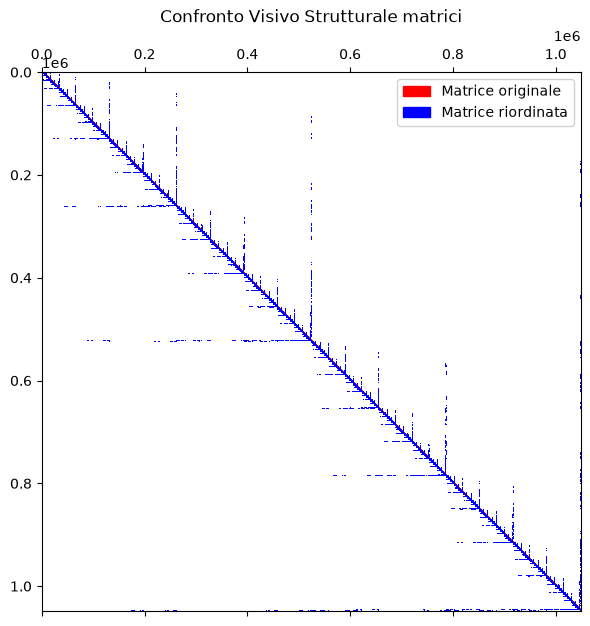

In [76]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches


def plot_solution_2d(u, N=None, title="Profilo di Temperatura 2D"):
    # Se N non viene fornito esplicitamente, lo calcoliamo dalla lunghezza del vettore u
    if N is None:
        N = int(np.sqrt(len(u)))

    nodi_totali = N * N

    # Reshape del vettore 1D nella griglia 2D NxN
    U_grid = u.reshape((N, N), order="F") # in questo modo, la griglia viene riempita colonna per colonna, che è coerente con l'ordine di memorizzazione dei dati .

    plt.figure(figsize=(7, 6))

    # Mappa di calore 2D (imshow)
    im = plt.imshow(U_grid, cmap="hot", origin="lower", extent=[0, 1, 0, 1])

    plt.colorbar(im, label="Temperatura $u(x,y)$")

    # Titolo con Profilo di Temperatura 2D, N e Nodi Totali
    plt.title(
        f"{title}\nN = {N} (Nodi totali: {nodi_totali})",
        fontsize=11,
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(False)
    plt.show()


#voglio riportare u_ord nell'ordine originale
#Caricamento del file di permutazione (colonna 0: m, colonna 1: n)
ordering = np.loadtxt("ordering.txt").astype(int)
m_indices = ordering[:, 0]  # Indici nel sistema riordinato
n_indices = ordering[:, 1]  # Indici nel sistema originale

#Inizializzazione del vettore ripristinato
if res_reord is not None:
     u_reord_restored = np.zeros_like(u_reord)


# Mappatura diretta: l'elemento in posizione m va nella posizione originale n
u_reord_restored[n_indices] = u_reord[m_indices]

#Verifica della coincidenza tra la soluzione originale e quella ripristinata
if res_orig is not None:
       diff = np.linalg.norm(u_orig - u_reord_restored) / np.linalg.norm(u_orig)
       print(f"Differenza relativa tra u_orig e u_reord_restored: {diff:.2e}") 



#plot per il sistema orginale se u_orig è sato prodotto altrimento con il sistema riordinato
if res_orig is not None:
    
    plot_solution_2d(u_orig, title="Profilo di Temperatura 2D")
    
else:
    
    plot_solution_2d(u_reord_restored, title="Profilo di Temperatura 2D")
    
#creazione immagini struttura della marice

plt.figure(figsize=(7, 7))

# Grafico della prima matrice in rosso (quadrati)
plt.spy(A_orig, color='red', marker=',', label='Elementi matrice originale')

# Sovrapposizione della seconda matrice in blu (cerchi)
plt.spy(A_reordered, color='blue', marker=',', label='Elementi matrice riordinata')

plt.title("Confronto Visivo Strutturale matrici")
legend_elements = [
    mpatches.Patch(color='red', label='Matrice originale'),
    mpatches.Patch(color='blue', label='Matrice riordinata')
]

plt.legend(handles=legend_elements, framealpha=0.9)
plt.show()


